# BarClean fixed-scene 10 Hz cutpoint diagnostics

只读检查当前 10 Hz 数据中的四个阶段边界，重点放大 S2→S3。这个 notebook **不会写入或覆盖任何 NPZ 数据集**。

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
if project_root.name == 'experiments':
    project_root = project_root.parent
dataset_path = project_root / 'robot/stage_cons_iiwa14/data/processed/demo_fixed_scene_loader_export/demo_fixed_scene_7_demos_10hz_training.npz'

with np.load(dataset_path, allow_pickle=False) as archive:
    features = np.asarray(archive['features'], dtype=float)
    feature_names = [str(value) for value in archive['feature_names'].tolist()]
    bounds = np.asarray(archive['coarse_bounds_indices'], dtype=np.int64)
    sampling_hz = float(np.asarray(archive['downsample_hz']).item())
    annotation_kind = str(np.asarray(archive['cutpoint_annotation_kind']).item())
    annotation_source = str(np.asarray(archive['cutpoint_annotation_source']).item())

local_bounds = np.asarray([row - row[0] for row in bounds], dtype=np.int64)
print({
    'dataset': str(dataset_path),
    'sampling_hz': sampling_hz,
    'annotation_kind': annotation_kind,
    'annotation_source': annotation_source,
    'local_cutpoints': [row[1:-1].tolist() for row in local_bounds],
})

{'dataset': '/home/baiyu/PycharmProjects/LearnStageConstraint/robot/stage_cons_iiwa14/data/processed/demo_fixed_scene_loader_export/demo_fixed_scene_7_demos_10hz_training.npz', 'sampling_hz': 10.0, 'annotation_kind': '10hz_cp2_table_stability_lateral_002_with_manual_turn_onset_overrides', 'annotation_source': 'robot/stage_cons_iiwa14/data/processed/demo_fixed_scene_loader_export/demo_fixed_scene_7_demos_5hz_training.npz', 'local_cutpoints': [[76, 152, 168, 220], [68, 137, 156, 196], [76, 125, 148, 194], [74, 136, 150, 192], [70, 126, 140, 184], [90, 151, 162, 206], [72, 132, 148, 192]]}


## 四个 cutpoints 总览

红、蓝、绿、紫虚线依次表示 CP1–CP4。

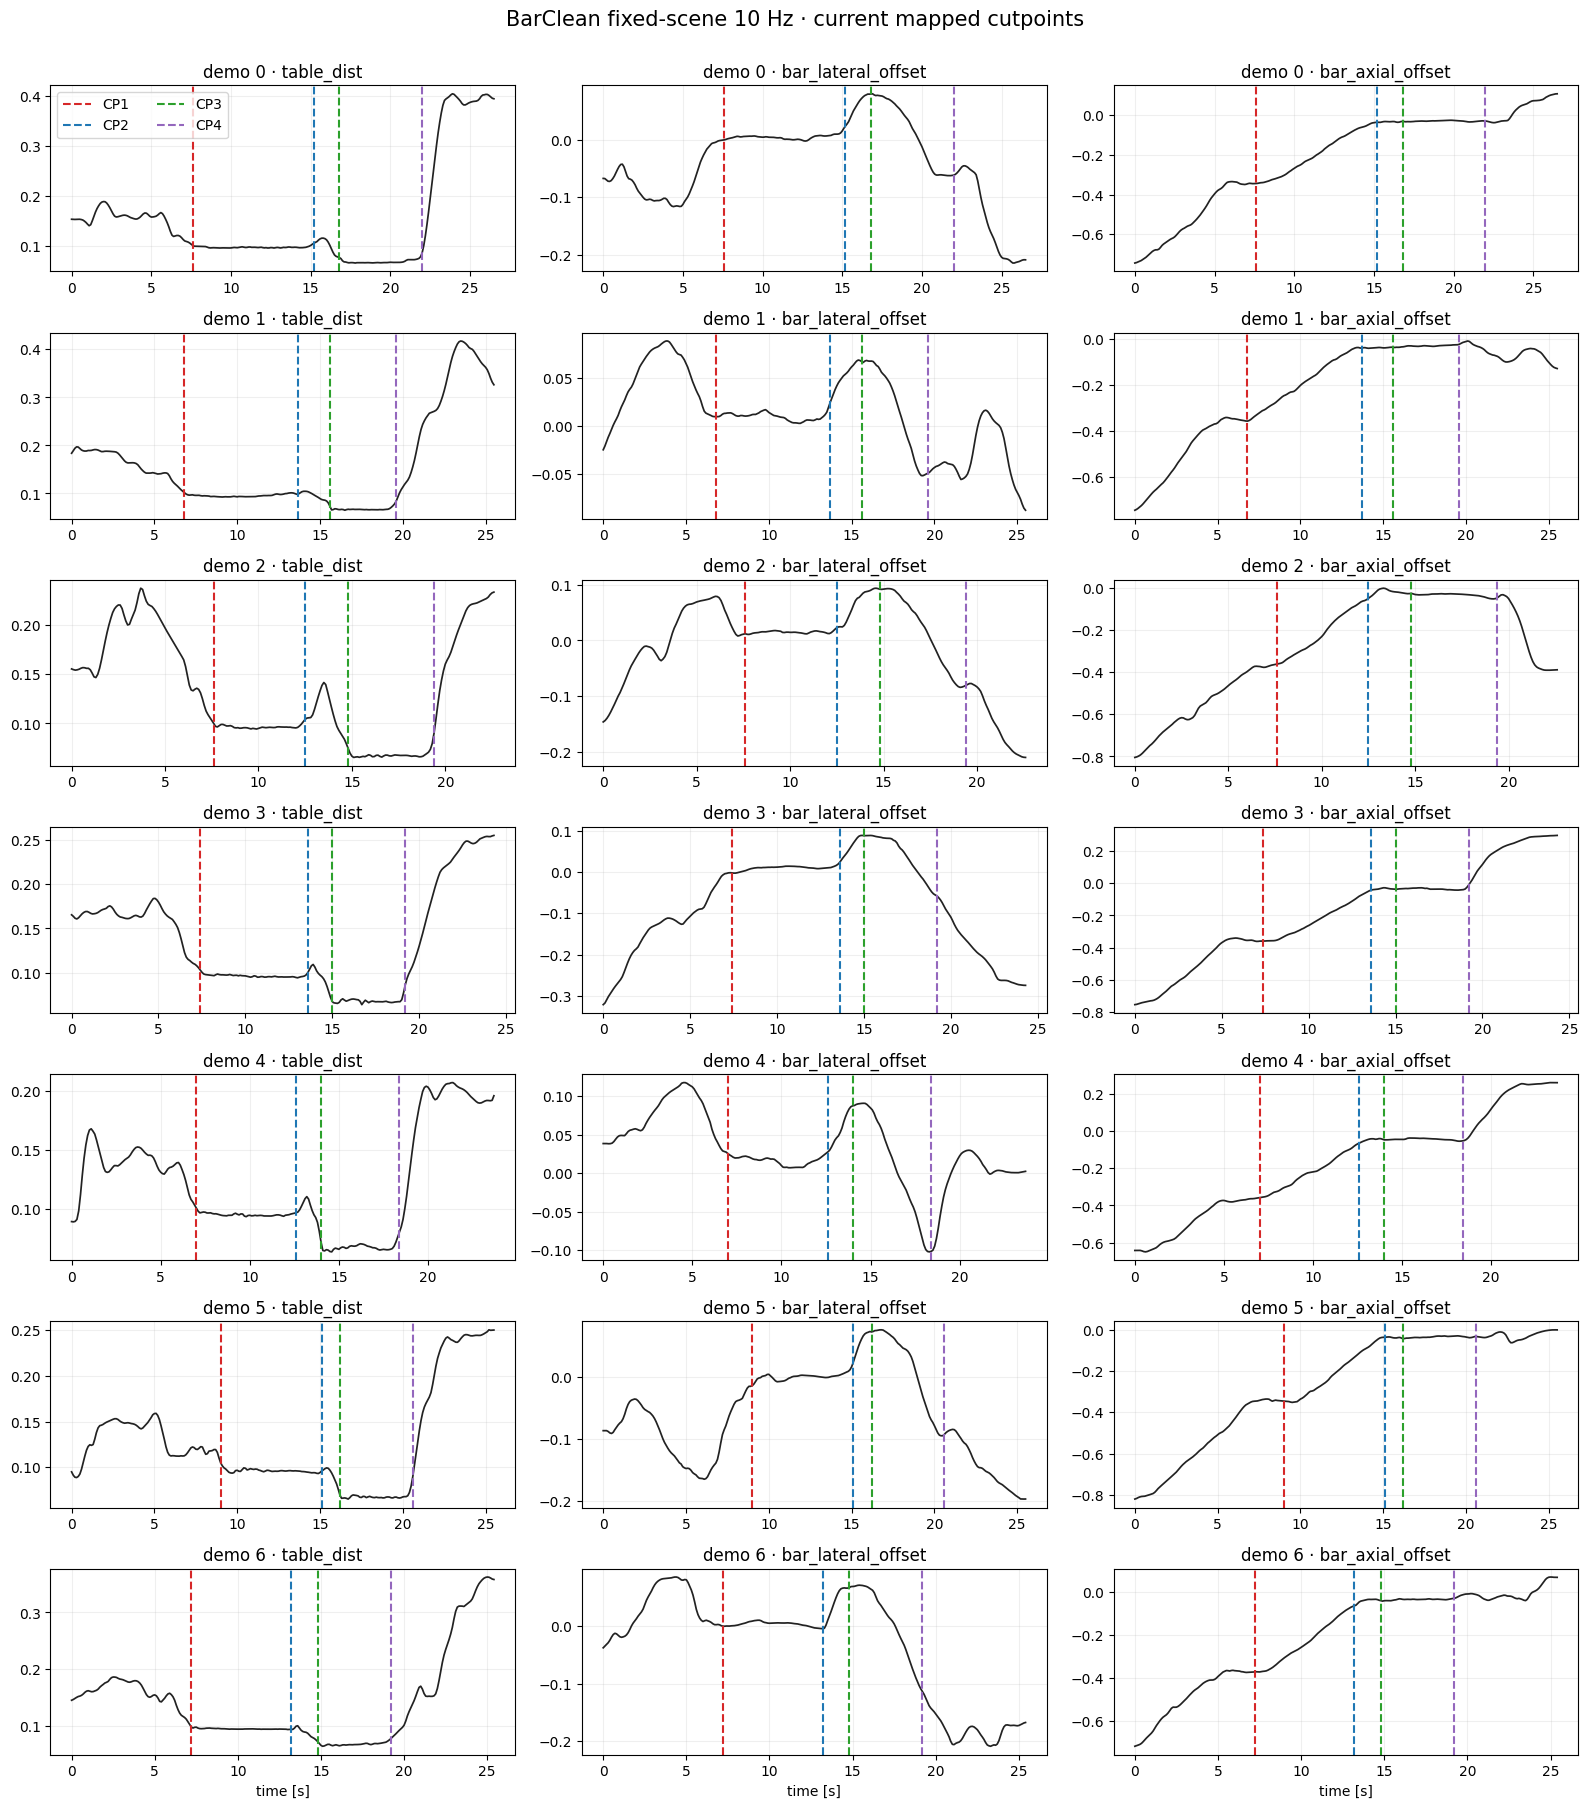

In [2]:
overview_features = ['table_dist', 'bar_lateral_offset', 'bar_axial_offset']
cutpoint_colors = ['#D62728', '#1F77B4', '#2CA02C', '#9467BD']
fig, axes = plt.subplots(len(bounds), len(overview_features), figsize=(16, 18), squeeze=False)
for demo_index, (row, local) in enumerate(zip(bounds, local_bounds)):
    begin, end = int(row[0]), int(row[-1])
    time_s = np.arange(end - begin, dtype=float) / sampling_hz
    for feature_index, feature_name in enumerate(overview_features):
        axis = axes[demo_index, feature_index]
        values = features[begin:end, feature_names.index(feature_name)]
        axis.plot(time_s, values, color='#222222', linewidth=1.25)
        for cutpoint_index, cutpoint in enumerate(local[1:-1]):
            axis.axvline(
                float(cutpoint) / sampling_hz,
                color=cutpoint_colors[cutpoint_index],
                linestyle='--',
                linewidth=1.5,
                label=f'CP{cutpoint_index + 1}' if demo_index == 0 and feature_index == 0 else None,
            )
        axis.grid(alpha=0.2)
        axis.set_title(f'demo {demo_index} · {feature_name}')
        if demo_index == len(bounds) - 1:
            axis.set_xlabel('time [s]')
axes[0, 0].legend(loc='best', ncol=2)
fig.suptitle('BarClean fixed-scene 10 Hz · current mapped cutpoints', fontsize=15, y=1.002)
fig.tight_layout()
plt.show()

## S2→S3 放大检查

红线是当前由 5 Hz 时间映射得到的 CP2。蓝线是直接在 10 Hz 数据上，将 lateral stable-band 收紧为 `|bar_lateral_offset| ≤ 0.02 m` 后重新计算的高位稳定区间终点。浅蓝区域表示该稳定区间。此处只比较和画图，不写回数据。

demo │ mapped CP2 │ 10 Hz stable-end │ Δsamples │ Δtime
─────┼────────────┼──────────────────┼──────────┼────────
   0 │        152 │              152 │       +0 │ +0.00 s
   1 │        137 │              137 │       +0 │ +0.00 s
   2 │        125 │              125 │       +0 │ +0.00 s
   3 │        136 │              136 │       +0 │ +0.00 s
   4 │        126 │              126 │       +0 │ +0.00 s
   5 │        151 │              151 │       +0 │ +0.00 s
   6 │        132 │              132 │       +0 │ +0.00 s


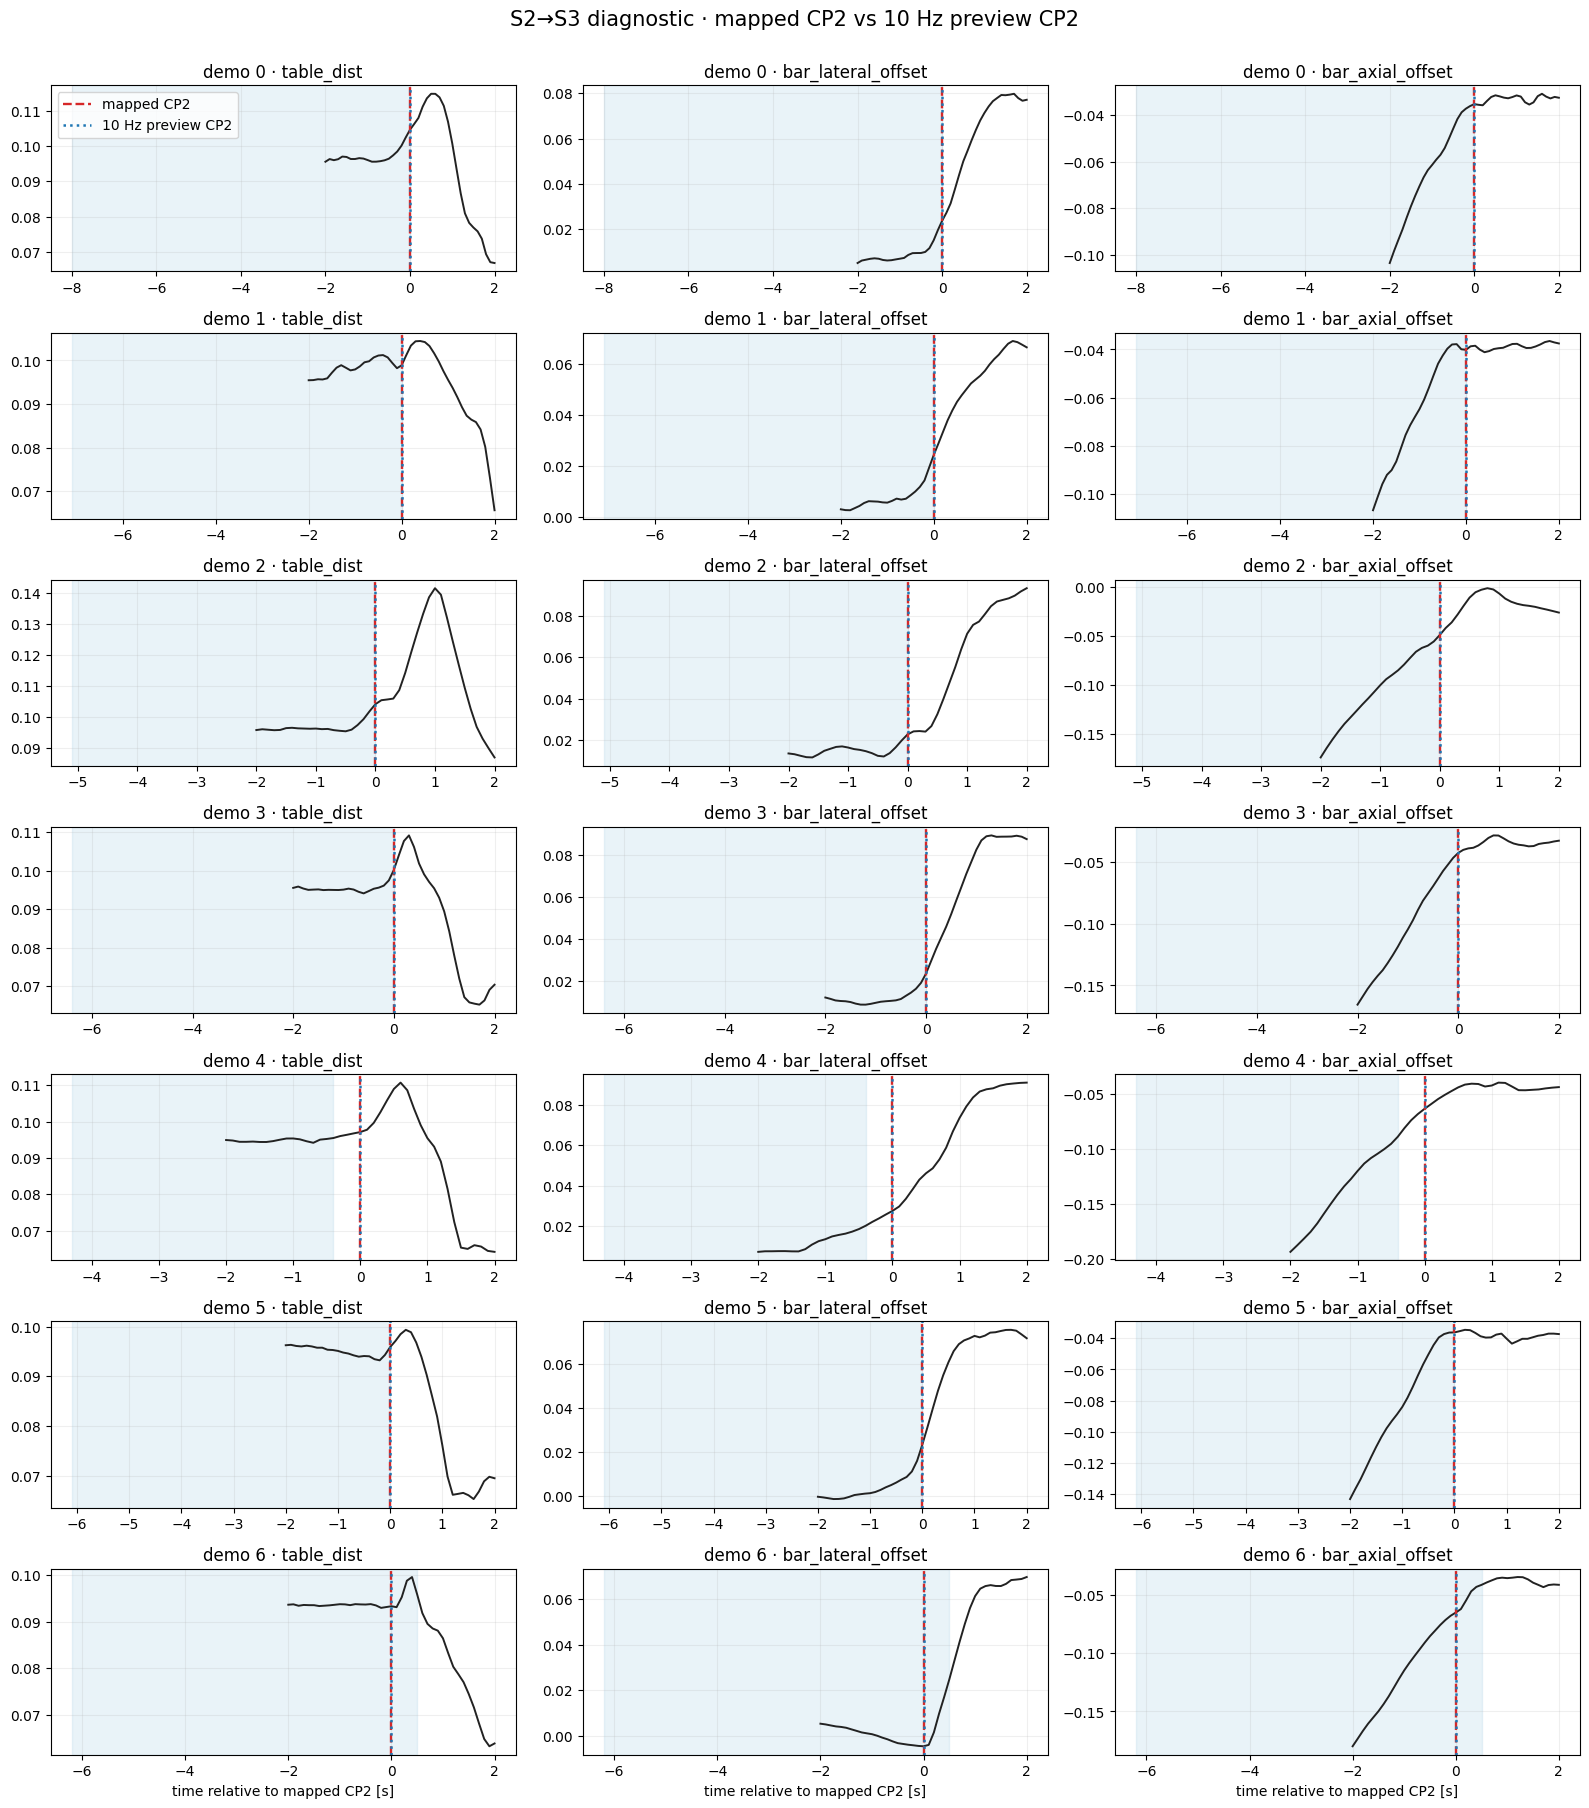

In [3]:
def contiguous_runs(mask):
    padded = np.r_[False, np.asarray(mask, dtype=bool), False]
    edges = np.flatnonzero(padded[1:] != padded[:-1])
    return [(int(begin), int(end)) for begin, end in edges.reshape(-1, 2)]

def longest_run(mask, minimum_length):
    runs = [run for run in contiguous_runs(mask) if run[1] - run[0] >= int(minimum_length)]
    return max(runs, key=lambda run: run[1] - run[0]) if runs else None

table_column = feature_names.index('table_dist')
lateral_column = feature_names.index('bar_lateral_offset')
minimum_stable_samples = int(round(1.6 * sampling_hz))
manual_cp2_overrides = {4: 126, 6: 132}
comparison = []
stable_runs = []
for demo_index, (row, local) in enumerate(zip(bounds, local_bounds)):
    begin, end = int(row[0]), int(row[-1])
    demo_features = features[begin:end]
    table = demo_features[:, table_column]
    lateral = demo_features[:, lateral_column]
    stable_high = longest_run(
        (table >= 0.088) & (table <= 0.108) & (np.abs(lateral) <= 0.020),
        minimum_length=minimum_stable_samples,
    )
    stable_runs.append(stable_high)
    mapped_cp2 = int(local[2])
    stable_band_cp2 = None if stable_high is None else int(stable_high[1])
    direct_10hz_cp2 = manual_cp2_overrides.get(demo_index, stable_band_cp2)
    comparison.append((demo_index, mapped_cp2, direct_10hz_cp2, None if direct_10hz_cp2 is None else direct_10hz_cp2 - mapped_cp2))

print('demo │ mapped CP2 │ 10 Hz stable-end │ Δsamples │ Δtime')
print('─────┼────────────┼──────────────────┼──────────┼────────')
for demo_index, mapped_cp2, direct_cp2, delta in comparison:
    direct_text = 'none' if direct_cp2 is None else str(direct_cp2)
    delta_text = 'none' if delta is None else f'{delta:+d}'
    time_text = 'none' if delta is None else f'{delta / sampling_hz:+.2f} s'
    print(f'{demo_index:>4d} │ {mapped_cp2:>10d} │ {direct_text:>16s} │ {delta_text:>8s} │ {time_text}')

zoom_features = ['table_dist', 'bar_lateral_offset', 'bar_axial_offset']
window_seconds = 2.0
window_samples = int(round(window_seconds * sampling_hz))
fig, axes = plt.subplots(len(bounds), len(zoom_features), figsize=(16, 18), squeeze=False)
for demo_index, (row, local, stable_high) in enumerate(zip(bounds, local_bounds, stable_runs)):
    begin, end = int(row[0]), int(row[-1])
    mapped_cp2 = int(local[2])
    preview_cp2 = manual_cp2_overrides.get(demo_index, None if stable_high is None else int(stable_high[1]))
    left = max(0, mapped_cp2 - window_samples)
    right = min(end - begin, mapped_cp2 + window_samples + 1)
    relative_time_s = (np.arange(left, right) - mapped_cp2) / sampling_hz
    for feature_index, feature_name in enumerate(zoom_features):
        axis = axes[demo_index, feature_index]
        values = features[begin + left:begin + right, feature_names.index(feature_name)]
        axis.plot(relative_time_s, values, color='#222222', linewidth=1.4)
        axis.axvline(0.0, color='#D62728', linestyle='--', linewidth=1.7, label='mapped CP2' if demo_index == 0 and feature_index == 0 else None)
        if stable_high is not None:
            stable_begin_s = (stable_high[0] - mapped_cp2) / sampling_hz
            stable_end_s = (stable_high[1] - mapped_cp2) / sampling_hz
            axis.axvspan(stable_begin_s, stable_end_s, color='#9ECAE1', alpha=0.22)
        if preview_cp2 is not None:
            preview_time_s = (preview_cp2 - mapped_cp2) / sampling_hz
            axis.axvline(preview_time_s, color='#1F77B4', linestyle=':', linewidth=1.8, label='10 Hz preview CP2' if demo_index == 0 and feature_index == 0 else None)
        axis.grid(alpha=0.2)
        axis.set_title(f'demo {demo_index} · {feature_name}')
        if demo_index == len(bounds) - 1:
            axis.set_xlabel('time relative to mapped CP2 [s]')
axes[0, 0].legend(loc='best')
fig.suptitle('S2→S3 diagnostic · mapped CP2 vs 10 Hz preview CP2', fontsize=15, y=1.002)
fig.tight_layout()
plt.show()